**M4 Daily Time Series: Comparative Analysis of ES-RNN vs. LightGBM**
- Uses a SINGLE pre-calculated CSV containing all metrics, correlation, winner, and trend.
- Analyzes the relationship between trend and forecast performance/correlation.
- Performs statistical tests.
- Generates visualizations.

In [10]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
import warnings

# Configure plotting style and font
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['DejaVu Serif']
rcParams['font.size'] = 12
sns.set_style("whitegrid")


# --- Define Paths ---
DATA_PATH = "/kaggle/input/m4-competiton-coparative-analysis/" 
ANALYSIS_FILE = DATA_PATH + "analysis_df.csv"

# --- Load Data ---
try:
    analysis_df = pd.read_csv(ANALYSIS_FILE)
    if 'Unnamed: 0' in analysis_df.columns:
        analysis_df = analysis_df.drop(columns=['Unnamed: 0'])
    if 'new_trend_Acomulada' in analysis_df.columns:
        analysis_df = analysis_df.rename(columns={'new_trend_Acomulada': 'trend'})
    elif 'trend' not in analysis_df.columns:
        raise ValueError("Trend column ('new_trend_Acomulada' or 'trend') not found.")

    required_cols = [ 'serie', 'sMAPE_ESRNN', 'MAE_ESRNN', 'MAPE_ESRNN', 'RMSE_ESRNN', 'sMAPE_LGBM', 'MAE_LGBM', 'MAPE_LGBM', 'RMSE_LGBM', 'correlation', 'winner', 'trend']
    if not all(col in analysis_df.columns for col in required_cols):
        missing = [col for col in required_cols if col not in analysis_df.columns]
        raise ValueError(f"Combined analysis file is missing required columns: {missing}")

    print(f"Successfully loaded combined analysis data. Shape: {analysis_df.shape}")
    print(analysis_df.head())

except FileNotFoundError as e:
    print(f"Error: Combined analysis file not found at {ANALYSIS_FILE}")
    analysis_df = pd.DataFrame()
except Exception as e:
    print(f"An error occurred loading/checking the combined data: {e}")
    analysis_df = pd.DataFrame()

Successfully loaded combined analysis data. Shape: (2724, 12)
  serie  sMAPE_ESRNN    MAE_ESRNN  MAPE_ESRNN   RMSE_ESRNN  sMAPE_LGBM  \
0    D1     1.296944    26.603170    1.287552    28.242924   19.341024   
1    D2     0.928656    27.900714    0.919856    40.549106    1.257448   
2    D6     5.118614   164.396068    4.964824   182.004938   54.112424   
3    D7    31.607398  1918.778455   30.133036  2171.008056   42.528841   
4    D8     0.489877     8.540982    0.491425    11.456555   12.149051   

      MAE_LGBM  MAPE_LGBM    RMSE_LGBM  correlation  winner  trend  
0   363.636183  17.634031   363.877524     0.831126       0      7  
1    37.791939   1.256516    44.248545     0.628759       0      5  
2  1394.508458  42.572966  1397.487947     0.568809       0      3  
3  2475.482484  34.980921  2811.356992    -0.014365       0     -1  
4   199.264105  11.452574   199.400044    -0.112225       0     -1  


In [11]:
# # 2. Analysis and Visualization (Using Combined Data)

def create_histogram_by_winner(df, title):
    """
    Creates a histogram of correlation values split by winner model.
    Assumes df has 'correlation' and 'winner' columns (0=ESRNN, 1=LGBM).
    Calculates mean using absolute correlation values.
    """
    if 'correlation' not in df.columns or 'winner' not in df.columns:
        print("Error: DataFrame must contain 'correlation' and 'winner' columns.")
        return None
    # Drop NaNs in correlation for accurate plotting and stats
    df_plot = df.dropna(subset=['correlation'])
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(12, 6))
    # Split data by winner
    lgbm_corr = df_plot[df_plot['winner'] == 1]['correlation']
    esrnn_corr = df_plot[df_plot['winner'] == 0]['correlation']
    # Create histogram bins
    bins = np.linspace(-1, 1, 21)  # 20 bins from -1 to 1
    # Plot histograms
    ax.hist(lgbm_corr, bins=bins, alpha=0.7, label='LightGBM', color='#6790f0') # Blue for LGBM wins
    ax.hist(esrnn_corr, bins=bins, alpha=0.7, label='ES-RNN', color='#f59d05') # Light blue/grey for ESRNN wins
    # Add labels and title
    ax.set_xlabel('Correlation values', fontsize=14 ,fontfamily='DejaVu Serif')
    ax.set_ylabel('Frequency', fontsize=14 ,fontfamily='DejaVu Serif')
    ax.set_title(title if title else ' ', fontsize=16,fontfamily='DejaVu Serif')
    ax.legend(prop={'family': 'DejaVu Serif', 'size': 11})
    # Add grid
    ax.grid(True, linestyle='--', alpha=0.7)
    # Add text with summary statistics - using absolute correlation values for mean
    lgbm_n = len(lgbm_corr)
    esrnn_n = len(esrnn_corr)
    
    # Calculate means with absolute correlation values
    lgbm_abs_mean = lgbm_corr.abs().mean() if lgbm_n > 0 else np.nan
    esrnn_abs_mean = esrnn_corr.abs().mean() if esrnn_n > 0 else np.nan
    
    # Also keep the regular mean for comparison
    lgbm_mean = lgbm_corr.mean() if lgbm_n > 0 else np.nan
    esrnn_mean = esrnn_corr.mean() if esrnn_n > 0 else np.nan
    
    lgbm_stats = f"LightGBM : n={lgbm_n}, abs_mean={lgbm_abs_mean:.2f}"
    esrnn_stats = f"ES-RNN : n={esrnn_n},  abs_mean={esrnn_abs_mean:.2f}"
    
    ax.text(0.75, 0.95, lgbm_stats, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', fontfamily='DejaVu Serif',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.text(0.75, 0.87, esrnn_stats, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', fontfamily='DejaVu Serif',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    # Set tick fonts
    ax.tick_params(axis='both', which='major', labelsize=11)
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontname('DejaVu Serif')
    plt.tight_layout()
    return fig


Summary of Comparison between Methods (based on pre-calculated metrics):
       ES-RNN Wins  LGBM Wins  Ties  ES-RNN Win %  LGBM Win %
sMAPE       1226.0     1498.0   0.0     45.007342   54.992658
MAE         1231.0     1493.0   0.0     45.190896   54.809104
MAPE        1234.0     1490.0   0.0     45.301028   54.698972
RMSE        1262.0     1462.0   0.0     46.328928   53.671072


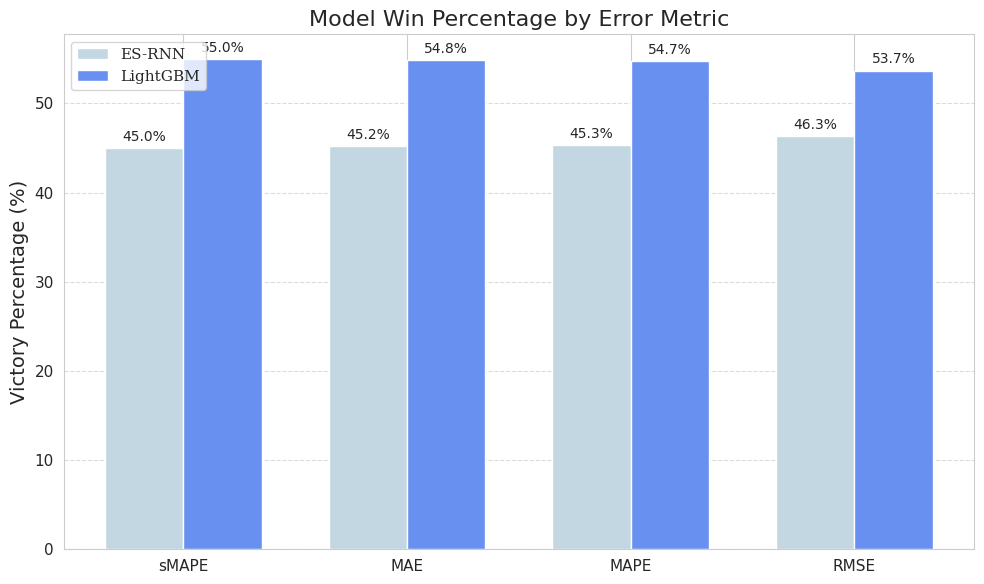

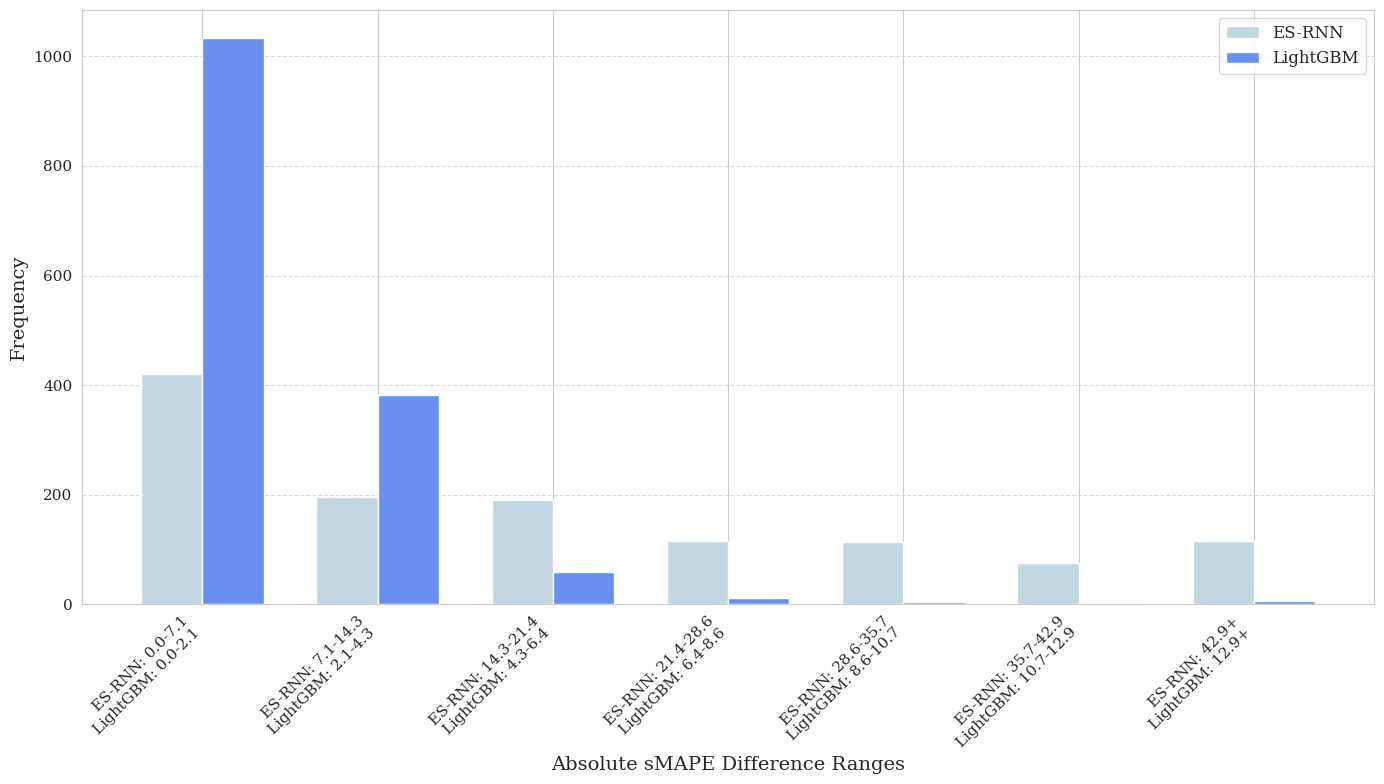


--- Correlation Distribution by Winning Model ---


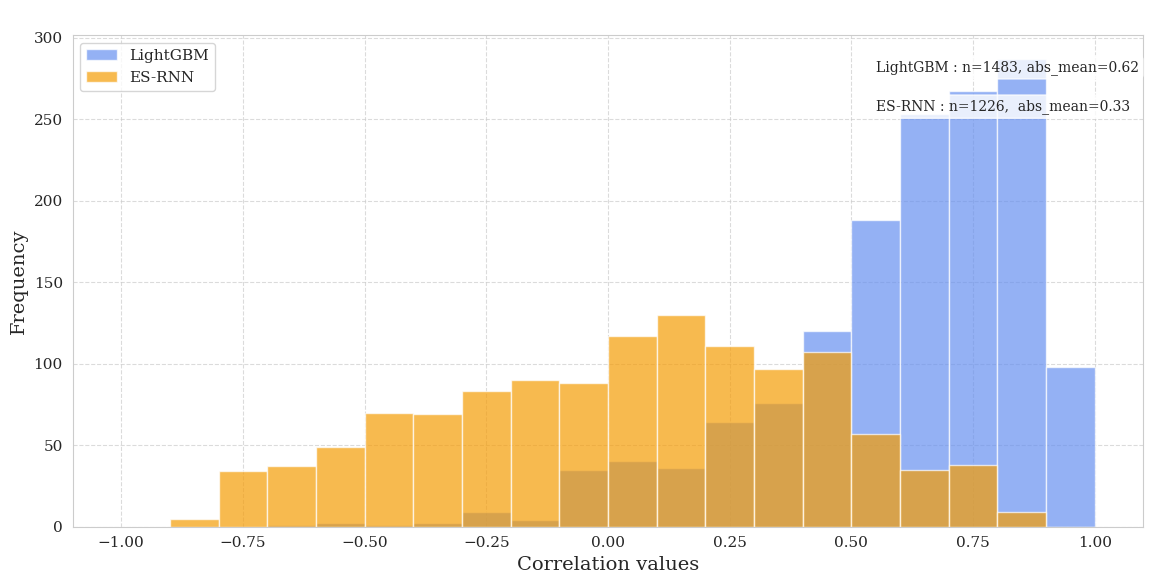


Shape for Trend/Correlation analysis after dropping NaNs: (2709, 20)


/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


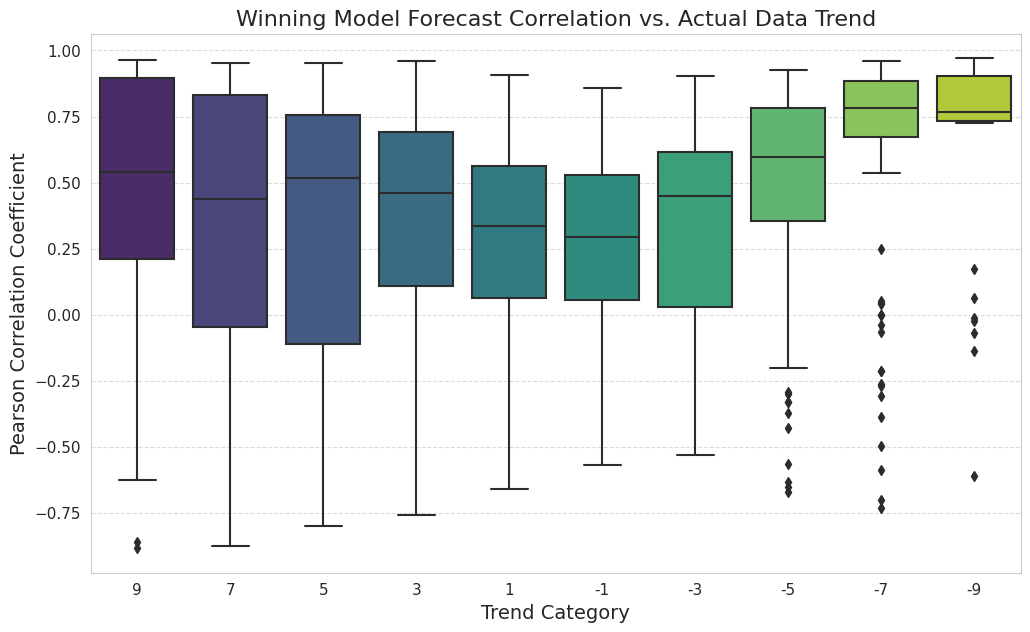

In [12]:
# --- Run Analysis and Generate Plots ---
if not analysis_df.empty:
    # --- 2a. Initial Performance Comparison (Based on Pre-loaded Metrics) ---
    metrics = ['sMAPE', 'MAE', 'MAPE', 'RMSE']
    comparison_summary = {}
    for metric in metrics:
        col_esrnn = f'{metric}_ESRNN'
        col_lgbm = f'{metric}_LGBM'
        analysis_df[f'{metric}_Winner'] = np.where(
            analysis_df[col_esrnn] < analysis_df[col_lgbm], 'ES-RNN',
            np.where(analysis_df[col_lgbm] < analysis_df[col_esrnn], 'LGBM', 'Tie')
        )
        analysis_df[f'{metric}_Diff'] = analysis_df[col_esrnn] - analysis_df[col_lgbm]
        
        wins_esrnn = (analysis_df[f'{metric}_Winner'] == 'ES-RNN').sum()
        wins_lgbm = (analysis_df[f'{metric}_Winner'] == 'LGBM').sum()
        ties = (analysis_df[f'{metric}_Winner'] == 'Tie').sum()
        total = len(analysis_df)
        
        percent_esrnn = wins_esrnn / total * 100 if total > 0 else 0
        percent_lgbm = wins_lgbm / total * 100 if total > 0 else 0
        
        comparison_summary[metric] = {
            'ES-RNN Wins': wins_esrnn,
            'LGBM Wins': wins_lgbm,
            'Ties': ties,
            'ES-RNN Win %': percent_esrnn,
            'LGBM Win %': percent_lgbm
        }
    
    df_comparison = pd.DataFrame(comparison_summary).T
    print("\nSummary of Comparison between Methods (based on pre-calculated metrics):")
    print(df_comparison)

    # --- 2b. Visualize Win Percentages ---
    metrics_names = list(df_comparison.index)
    x = np.arange(len(metrics_names))
    width = 0.35
    
    fig_winpct, ax_winpct = plt.subplots(figsize=(10, 6))
    bars_A = ax_winpct.bar(x - width/2, df_comparison['ES-RNN Win %'], width, color='#c3d7e3', label='ES-RNN')
    bars_B = ax_winpct.bar(x + width/2, df_comparison['LGBM Win %'], width, color='#6790f0', label='LightGBM')
    
    ax_winpct.set_ylabel('Victory Percentage (%)', fontsize=14)
    ax_winpct.set_xticks(x)
    ax_winpct.set_xticklabels(metrics_names, fontsize=12)
    ax_winpct.legend(prop={'family': 'DejaVu Serif', 'size': 11}, loc='upper left')
    ax_winpct.set_title('Model Win Percentage by Error Metric', fontsize=16)
    ax_winpct.tick_params(axis='both', which='major', labelsize=11)
    ax_winpct.grid(axis='y', linestyle='--', alpha=0.7)
    
    def autolabel(bars, ax_target):  # Pass axis to annotation function
        for bar in bars:
            height = bar.get_height()
            ax_target.annotate(
                f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center',
                va='bottom',
                fontsize=10
            )
    
    autolabel(bars_A, ax_winpct)
    autolabel(bars_B, ax_winpct)
    plt.tight_layout()
    plt.show()

    # --- 2c. Visualize sMAPE Difference Distribution (Absolute Difference) ---
    
    smape_diff = analysis_df['sMAPE_Diff']
    winner_lgbm_flag = analysis_df['winner']
    smape_diff_abs = np.abs(smape_diff)
    num_bins_total = 7
    rnn_wins_mask = (winner_lgbm_flag == 0)
    lgbm_wins_mask = (winner_lgbm_flag == 1)
    
    smape_diff_abs_rnn = smape_diff_abs[rnn_wins_mask]
    smape_diff_abs_lgbm = smape_diff_abs[lgbm_wins_mask]

    if (not smape_diff_abs_rnn.empty and not smape_diff_abs_rnn.isna().all()) and \
       (not smape_diff_abs_lgbm.empty and not smape_diff_abs_lgbm.isna().all()):
        
        # Establecer rangos máximos fijos para mejor visualización
        max_abs_diff_rnn = 50.0  # Límite para RNN
        max_abs_diff_lgbm = 15.0  # Límite para LGBM
        
        # Crear bins con los rangos especificados
        bins_rnn = np.linspace(0, max_abs_diff_rnn, num_bins_total + 1)
        bins_lgbm = np.linspace(0, max_abs_diff_lgbm, num_bins_total + 1)
        
        # Contar frecuencias para cada bin por método
        y_rnn_wins_counts = []
        for i in range(len(bins_rnn) - 1):
            lower = bins_rnn[i]
            upper = bins_rnn[i+1]
            
            # Para el último bin, incluir todos los valores que sean mayores o iguales al límite inferior
            if i == len(bins_rnn) - 2:
                mask = (smape_diff_abs_rnn >= lower)
            else:
                mask = (smape_diff_abs_rnn >= lower) & (smape_diff_abs_rnn < upper)
                
            y_rnn_wins_counts.append(mask.sum())
        
        y_lgbm_wins_counts = []
        for i in range(len(bins_lgbm) - 1):
            lower = bins_lgbm[i]
            upper = bins_lgbm[i+1]
            
            # Para el último bin, incluir todos los valores que sean mayores o iguales al límite inferior
            if i == len(bins_lgbm) - 2:
                mask = (smape_diff_abs_lgbm >= lower)
            else:
                mask = (smape_diff_abs_lgbm >= lower) & (smape_diff_abs_lgbm < upper)
                
            y_lgbm_wins_counts.append(mask.sum())
        
        # Crear la figura con un solo plot
        fig, ax = plt.subplots(figsize=(14, 8))
        
        # Crear posiciones para las barras
        x_pos = np.arange(num_bins_total)
        
        # Crear barras para ambos métodos
        rects1 = ax.bar(x_pos - width/2, y_rnn_wins_counts, width, label='ES-RNN', color='#c3d7e3')
        rects2 = ax.bar(x_pos + width/2, y_lgbm_wins_counts, width, label='LightGBM', color='#6790f0')
        
        # Añadir etiquetas, título y leyenda
        ax.set_xlabel('Absolute sMAPE Difference Ranges', fontsize=14, fontfamily='DejaVu Serif')
        ax.set_ylabel('Frequency', fontsize=14, fontfamily='DejaVu Serif')
        ax.set_title('', fontsize=16, fontfamily='DejaVu Serif')
        ax.set_xticks(x_pos)
        ax.legend(fontsize=12, prop={'family': 'DejaVu Serif'})
        
        # Añadir grid
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        ax.tick_params(axis='both', which='major', labelsize=11)
        
        # Crear etiquetas para el eje X con los rangos de bins
        x_labels = []
        
        for i in range(num_bins_total):
            # Para el último bin, indicar que incluye todos los valores mayores
            if i == num_bins_total - 1:
                rnn_label = f"{bins_rnn[i]:.1f}+"
                lgbm_label = f"{bins_lgbm[i]:.1f}+"
            else:
                rnn_label = f"{bins_rnn[i]:.1f}-{bins_rnn[i+1]:.1f}"
                lgbm_label = f"{bins_lgbm[i]:.1f}-{bins_lgbm[i+1]:.1f}"
                
            x_labels.append(f"ES-RNN: {rnn_label}\nLightGBM: {lgbm_label}")
        
        ax.set_xticklabels(x_labels, rotation=45, ha='right', fontfamily='DejaVu Serif')
        
        # Aplicar fuente DejaVu Serif a todos los elementos de texto
        for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
                    ax.get_xticklabels() + ax.get_yticklabels()):
            item.set_fontfamily('DejaVu Serif')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No hay suficientes datos para crear los histogramas.")

    # --- 2d. Visualize Correlation Distribution by Winner ---
    # Filter NaNs from correlation before plotting
    analysis_df_corr_filtered = analysis_df.dropna(subset=['correlation'])
    if not analysis_df_corr_filtered.empty:
        print("\n--- Correlation Distribution by Winning Model ---")
        fig_corr_hist = create_histogram_by_winner(analysis_df_corr_filtered, '')  # Use the function
        plt.show()
    else:
        print("\nCorrelation data contains too many NaNs for histogram.")

    # --- 2e. Trend vs. Correlation Analysis ---
    analysis_df_filtered = analysis_df.dropna(subset=['correlation', 'trend']).copy()
    print(f"\nShape for Trend/Correlation analysis after dropping NaNs: {analysis_df_filtered.shape}")
    if not analysis_df_filtered.empty:
        # --- Boxplot ---
        boxplot_data = analysis_df_filtered[(analysis_df_filtered['trend'] >= -9) & 
                                            (analysis_df_filtered['trend'] <= 9)].copy()
        boxplot_data['trend'] = pd.to_numeric(boxplot_data['trend'], errors='coerce')
        boxplot_data = boxplot_data.dropna(subset=['trend'])
        if not boxplot_data.empty:
            boxplot_data['trend'] = pd.Categorical(
                boxplot_data['trend'], 
                categories=sorted(boxplot_data['trend'].unique(), reverse=True), 
                ordered=True
            )
            plt.figure(figsize=(12, 7))
            sns.boxplot(x='trend', y='correlation', data=boxplot_data, palette='viridis')
            plt.title('Winning Model Forecast Correlation vs. Actual Data Trend', fontsize=16)
            plt.xlabel('Trend Category', fontsize=14)
            plt.ylabel('Pearson Correlation Coefficient', fontsize=14)
            plt.xticks(fontsize=11)
            plt.yticks(fontsize=11)
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.show()
        else: 
            print("No data available for boxplot after filtering trends -9 to +9.")
    else:
        print("No data available for Trend vs Correlation analysis after filtering NaNs.")
else:
    print("Initial data loading/merging failed. Analysis cannot proceed.")